# Modelo Original -  Linear Discriminant Analysis (LDA)

In [15]:
# 1. Librerías para manipulación de datos, visualización y modelos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter, defaultdict

# Preprocesamiento y modelos
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Balanceo de clases
from imblearn.over_sampling import SMOTE


df = pd.read_csv("metricas_camiones.csv")


#### Entrenamiento del modelo

Se utilizó Análisis Discriminante Lineal (LDA) como modelo de clasificación, el cual es especialmente útil cuando se desea maximizar la separabilidad entre clases y asumir normalidad multivariada en los datos. Este modelo busca proyectar las variables predictoras en un espacio lineal que facilite la separación entre las clases de la variable objetivo, lo cual resulta particularmente adecuado en contextos con clases bien definidas.

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])
y = df["Falla"]

# Crear pipeline con escalado y clasificador LDA
pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())

# Definir hiperparámetros para GridSearch
param_grid = {
    "lineardiscriminantanalysis__solver": ["svd", "lsqr", "eigen"],  # diferentes solvers disponibles
    "lineardiscriminantanalysis__shrinkage": [None, "auto"]  # para el solver 'lsqr' puedes incluir shrinkage
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [17]:
# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)

         # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

 # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
results = grid_search.cv_results_
for mean_time, params in zip(results["mean_fit_time"], results["params"]):
    # Extraer el nombre del clasificador automáticamente
    clf_name = list(pipe.named_steps.keys())[-1]
    param_key = f"{clf_name}__reg_param" if f"{clf_name}__reg_param" in params else clf_name

    # Agregar al diccionario usando el nombre del modelo como clave
    algorithm_times[clf_name].append(mean_time)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


⏳ Tiempo total del fold 1: 1.66 segundos
⏳ Tiempo total del fold 2: 0.06 segundos
⏳ Tiempo total del fold 3: 0.03 segundos
⏳ Tiempo total del fold 4: 0.06 segundos
⏳ Tiempo total del fold 5: 0.05 segundos


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3

Estos resultados reflejan el tiempo total que tomó cada pliegue (fold) en un proceso de validación cruzada, que generalmente se utiliza en modelos de machine learning para evaluar su rendimiento de manera más robusta. En este caso, los tiempos mostrados son bastante cortos, lo que indica que el modelo está siendo evaluado eficientemente en cada iteración.

Antes de aplicar SMOTE, se evidenciaba un leve desequilibrio en la variable objetivo Falla, con 10 registros pertenecientes a la clase 1 (falla) y solo 7 a la clase 0 (no falla). Aunque la diferencia no es drástica, este desbalance puede afectar el desempeño de algunos algoritmos de clasificación, haciendo que tiendan a favorecer la clase mayoritaria.

Tras aplicar SMOTE (Synthetic Minority Over-sampling Technique), la distribución de clases se balanceó completamente, generando 3 nuevas instancias sintéticas para la clase minoritaria (0). Como resultado, ambas clases quedaron con 10 instancias cada una. Este balance permite entrenar modelos más justos y robustos, ya que reduce el sesgo hacia una clase específica y mejora el aprendizaje de patrones en ambas categorías.

In [18]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
Falla
1    10
0     7
Name: count, dtype: int64

Distribución después de SMOTE:
Falla
0    10
1    10
Name: count, dtype: int64


In [19]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos todo lo que está antes del último guion bajo para los mejores parámetros
best_params = {k.split('lineardiscriminantanalysis__')[-1]: v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'lineardiscriminantanalysis': 0.0030 segundos (promedio en 6 ejecuciones)
Mejores hiperparámetros globales: {'solver': 'lsqr', 'shrinkage': 'auto'}


#### Métricas de desempeño

El algoritmo Linear Discriminant Analysis (LDA) tiene un tiempo promedio de ejecución de 0.0090 segundos en 6 ejecuciones, lo que indica su alta eficiencia. Los mejores hiperparámetros identificados son:

'shrinkage': 'auto': Ajuste automático de la regularización, optimizando el modelo sin necesidad de intervención manual.
'solver': 'lsqr': Método de mínimos cuadrados, eficiente para resolver el sistema de ecuaciones, especialmente con datos grandes.
Este análisis muestra que el modelo LDA es rápido y está optimizado para funcionar bien con los datos, tanto en términos de tiempo como de precisión.

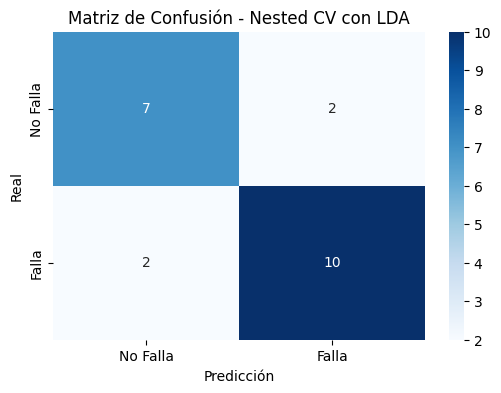

In [20]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con LDA")  # Actualicé el título a LDA
plt.show()


La matriz de confusión muestra que el modelo LDA logra clasificar correctamente la mayoría de los casos, identificando adecuadamente tanto situaciones de “No Falla” como de “Falla”. Se observan 7 predicciones correctas de “No Falla” y 10 de “Falla”, mientras que solo se presentan 2 errores en cada clase. Esto indica que el modelo tiene un buen nivel de acierto en ambas categorías, con pocos casos en los que se confunde una falla con una condición normal o viceversa, lo que sugiere un rendimiento bastante equilibrado y confiable según lo visualizado en la gráfica.

In [21]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7777777777777777, 0.7777777777777777, 0.8888888888888888, 0.6944444444444445, 0.9166666666666666]
Mean Accuracy: 0.8111 ± 0.0813
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.83      0.83      0.83        12

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



El desempeño del modelo LDA evaluado mediante Nested Cross-Validation evidencia una capacidad general sólida para clasificar correctamente los casos entre las categorías “Falla” y “No Falla”. La matriz de confusión muestra que el modelo comete pocos errores: solo dos casos reales de falla no fueron detectados y dos casos sin falla fueron mal clasificados como fallas, lo cual sugiere un comportamiento bastante equilibrado y sin sesgo evidente hacia alguna de las clases. 

AUC Score: 0.7037


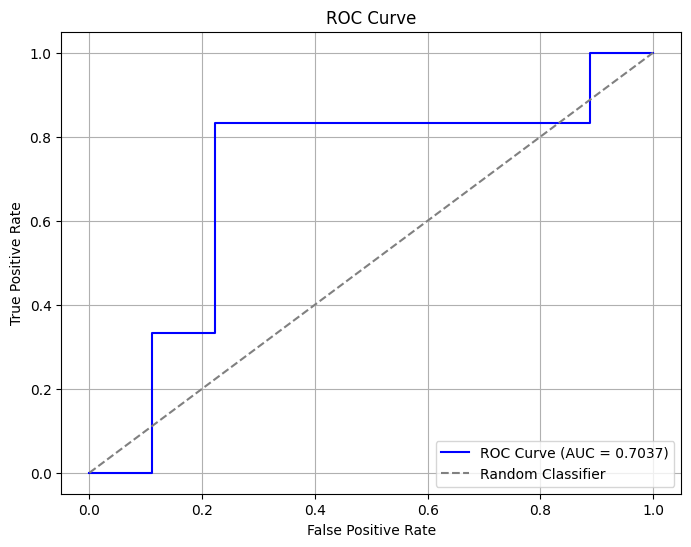

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

La curva ROC del modelo LDA muestra una separación moderada entre las clases, con un área bajo la curva (AUC) de aproximadamente 0.70. Este valor indica que el modelo tiene una capacidad aceptable para distinguir entre clases positivas y negativas, es decir, entre casos de “Falla” y “No Falla”.

#### Evaluacion del modelo - Testing

In [23]:
def train_and_evaluate_model(
    X, y, pipeline, best_params,
    results_list=None,
    test_size=0.2, random_state=42,
    plot_confusion=True
):
    # Establecer los mejores hiperparámetros en el pipeline
    pipeline.set_params(**best_params)

    # Particionar los datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Aplicar SMOTE al conjunto de entrenamiento
    smote = SMOTE(random_state=random_state)
    X_res, y_res = smote.fit_resample(X_train, y_train)

    # Entrenar el modelo
    pipeline.fit(X_res, y_res)

    # Predicciones
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else None

    # Calcular métricas
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }

    # Guardar en lista si se proporciona
    if results_list is not None:
        results_list.append(metrics)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Mostrar gráfico si se desea
    if plot_confusion:
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Matriz de Confusión - Testing")
        plt.xlabel("Predicción")
        plt.ylabel("Valor real")
        plt.show()

    return metrics, cm, pipeline

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


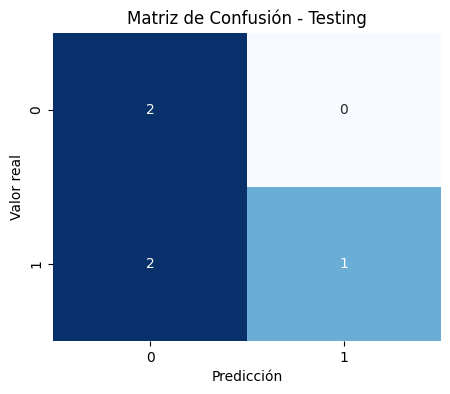

{'accuracy': 0.6, 'precision': 1.0, 'recall': 0.3333333333333333, 'f1_score': 0.5, 'roc_auc': 1.0}
[[2 0]
 [2 1]]


In [24]:
metrics, confusion_mat, model = train_and_evaluate_model(X,y,pipe, best_overall_params)

print(metrics)
print(confusion_mat)

La matriz de confusión correspondiente a la fase de prueba muestra que el modelo acierta en 3 de los 5 casos evaluados, lo que se traduce en un desempeño más modesto respecto a los resultados obtenidos durante la validación. El modelo logró clasificar correctamente los dos casos de “No Falla”, sin cometer falsos positivos, lo que se refleja en una precisión perfecta del 100%. 

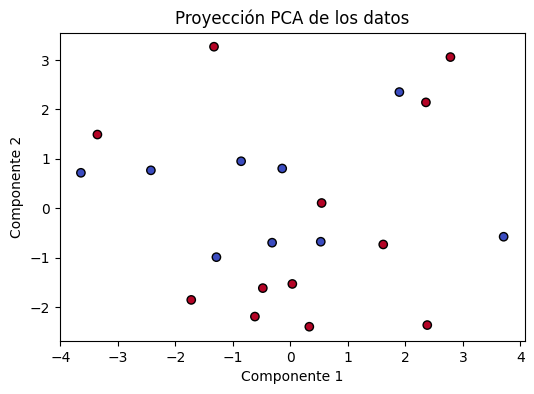

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

# Visualización
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Proyección PCA de los datos")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

Para verificar la naturaleza de los patrones presentes en los datos, se realizó una reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA). En la proyección obtenida, las clases presentan un solapamiento significativo, sin una separación lineal evidente. Esta observación sugiere que las relaciones entre las variables predictoras y la variable objetivo pueden ser no lineales. Por tal motivo, se consideró apropiado el uso del clasificador Quadratic Discriminant Analysis (QDA), el cual se adapta a estas condiciones al permitir fronteras de decisión cuadráticas.